In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df.shape

(42000, 785)

In [15]:
x,y = df.iloc[:,1:], df.iloc[:,0]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       816
           1       0.94      0.99      0.97       909
           2       0.96      0.93      0.94       846
           3       0.92      0.94      0.93       937
           4       0.95      0.94      0.95       839
           5       0.91      0.92      0.91       702
           6       0.95      0.97      0.96       785
           7       0.94      0.92      0.93       893
           8       0.97      0.87      0.92       835
           9       0.91      0.92      0.91       838

    accuracy                           0.94      8400
   macro avg       0.94      0.94      0.94      8400
weighted avg       0.94      0.94      0.94      8400



## Applying PCA

In [18]:
pca = PCA(n_components=150)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

knn.fit(x_train_pca, y_train)
y_pred_pca = knn.predict(x_test_pca)
print(classification_report(y_test, y_pred_pca))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       816
           1       0.96      0.99      0.98       909
           2       0.96      0.95      0.95       846
           3       0.94      0.94      0.94       937
           4       0.97      0.95      0.96       839
           5       0.93      0.93      0.93       702
           6       0.96      0.98      0.97       785
           7       0.96      0.94      0.95       893
           8       0.95      0.92      0.94       835
           9       0.93      0.94      0.93       838

    accuracy                           0.95      8400
   macro avg       0.95      0.95      0.95      8400
weighted avg       0.95      0.95      0.95      8400



Better result with 100 featues

In [26]:
# eigen values
pca.explained_variance_

array([40.67111198, 29.17023401, 26.74459621, 20.85344792, 18.14891878,
       15.8529825 , 13.87108101, 12.48058967, 11.02794236, 10.09582533,
        9.63317821,  8.62785945,  8.06303131,  7.89511749,  7.44167929,
        7.17032873,  6.73266373,  6.62744023,  6.41499161,  6.25808269,
        5.90495742,  5.76521585,  5.52084601,  5.32003847,  5.18309925,
        4.93439597,  4.90652171,  4.71800493,  4.49824444,  4.43140305,
        4.32604521,  4.23491831,  4.10335015,  4.0673118 ,  4.02362178,
        3.84130473,  3.81886146,  3.71316498,  3.60918108,  3.47303214,
        3.42842989,  3.38841159,  3.29157511,  3.22927379,  3.21745142,
        3.15810372,  3.12620905,  3.10412385,  3.05892795,  3.03728188,
        2.96540461,  2.94033669,  2.86828564,  2.82617865,  2.80038441,
        2.77411221,  2.71978838,  2.69394232,  2.64724369,  2.63065837,
        2.56498699,  2.53651735,  2.48789582,  2.44610051,  2.42066567,
        2.37577156,  2.35505085,  2.33408709,  2.29804042,  2.25

In [24]:
# eigen vectors
pca.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

### Finding Optimum Number of Features

In [34]:
pca = PCA(n_components=784)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

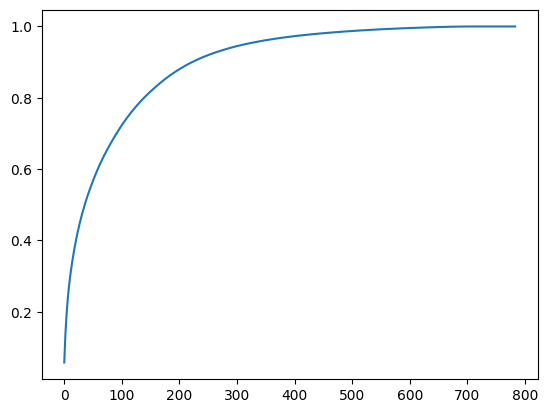

In [35]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [36]:
pca = PCA(n_components=250)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

knn.fit(x_train_pca, y_train)
y_pred_pca = knn.predict(x_test_pca)

print(classification_report(y_test, y_pred_pca))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       816
           1       0.95      0.99      0.97       909
           2       0.96      0.94      0.95       846
           3       0.94      0.94      0.94       937
           4       0.97      0.95      0.96       839
           5       0.92      0.93      0.92       702
           6       0.96      0.97      0.96       785
           7       0.95      0.93      0.94       893
           8       0.96      0.91      0.93       835
           9       0.93      0.93      0.93       838

    accuracy                           0.95      8400
   macro avg       0.95      0.95      0.95      8400
weighted avg       0.95      0.95      0.95      8400

